# MedAssist — Analyse Exploratoire des Données (EDA)

**Auteur** : Mouhamed Diop  ·  **Encadrant** : Mously DIAW
**Dataset** : [Asclepius Synthetic Clinical Notes](https://huggingface.co/datasets/starmpcc/Asclepius-Synthetic-Clinical-Notes)

Cette analyse est réalisée **en amont** de l'implémentation du système RAG. Son objectif
est de comprendre la structure, la qualité et les caractéristiques du corpus de notes
cliniques afin de **justifier les choix de conception** du pipeline RAG :

- taille de découpage des documents (`chunk_size`, `chunk_overlap`) ;
- choix du modèle d'embedding et de sa dimension (`all-MiniLM-L6-v2`, 384) ;
- nombre de passages à récupérer (`top_k`) ;
- métadonnées à conserver (`note_id`, `patient_id`, `task`) ;
- séparabilité de l'espace vectoriel sur lequel repose le retrieval.

---

## 0. Configuration et imports

In [1]:
import sys, re
from collections import Counter

sys.path.insert(0, "..")  # accès au package src/ du projet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_colwidth", 120)
print("Environnement prêt.")

C:\dev\medassist\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environnement prêt.


## 1. Chargement du dataset

On charge le split `train` complet. Le système RAG, lui, n'ingère que les
**500 premiers exemples** (sous-ensemble de développement) — on gardera cette
distinction en tête.

In [2]:
dataset = load_dataset("starmpcc/Asclepius-Synthetic-Clinical-Notes", split="train")
df = dataset.to_pandas()
print(f"Nombre total d'exemples : {len(df):,}")
print(f"Colonnes : {list(df.columns)}")
df.head(3)

Nombre total d'exemples : 158,114
Colonnes : ['patient_id', 'note', 'question', 'answer', 'task']


,patient_id,note,question,answer,task
0,0,Discharge Summary:\n\nPatient: 60-year-old male with moderate ARDS from COVID-19\n\nHospital Course:\n\nThe patient ...,"Can you provide a simplified paraphrase of the sentence, 'To avoid rapid deterioration and respiratory failure, a st...",The healthcare team used a gradual approach to changing the patient's position to avoid worsening of the respiratory...,Paraphrasing
1,1,Discharge Summary:\n\nAdmission Date: [Insert Date]\nDischarge Date: [Insert Date]\n\nPatient Name: [Insert Name]\nA...,Which coreferences were resolved in the hospital course section related to the patient's respiratory tract infection?,The hospital course section resolved the coreferences related to the patient's respiratory tract infection by provid...,Coreference Resolution
2,2,Hospital Course Summary:\n\nAdmission Date: [Insert date]\nDischarge Date: [Insert date]\n\nPatient: [Patient's Name...,"What were the key improvements in the patient's medical condition during the hospital course, and how was physical t...","During the hospital course, the patient's medical condition improved significantly, with his breathing frequency dec...",Summarization


### Schéma des colonnes

| Colonne | Type | Description |
|---|---|---|
| `patient_id` | int | Identifiant du patient / de la note clinique |
| `note` | str | Compte-rendu clinique (discharge summary) |
| `question` | str | Instruction / question posée sur la note |
| `answer` | str | Réponse de référence |
| `task` | str | Type de tâche NLP (8 catégories) |

In [3]:
ex = df.iloc[0]
for col in ["patient_id", "task", "note", "question", "answer"]:
    print(f"=== {col} ===")
    print(str(ex[col])[:400])
    print()

=== patient_id ===
0

=== task ===
Paraphrasing

=== note ===
Discharge Summary:

Patient: 60-year-old male with moderate ARDS from COVID-19

Hospital Course:

The patient was admitted to the hospital with symptoms of fever, dry cough, and dyspnea. During physical therapy on the acute ward, the patient experienced coughing attacks that induced oxygen desaturation and dyspnea with any change of position or deep breathing. To avoid rapid deterioration and resp

=== question ===
Can you provide a simplified paraphrase of the sentence, 'To avoid rapid deterioration and respiratory failure, a step-by-step approach was used for position changes' in the patient's discharge summary?

=== answer ===
The healthcare team used a gradual approach to changing the patient's position to avoid worsening of the respiratory status and prevent respiratory failure.



## 2. Qualité des données

Valeurs manquantes, chaînes vides et doublons — points critiques avant toute
ingestion dans un index vectoriel.

In [4]:
quality = pd.DataFrame({
    "valeurs_manquantes": df.isna().sum(),
    "chaines_vides": df.astype(str).apply(lambda c: c.str.strip() == "").sum(),
})
quality

,valeurs_manquantes,chaines_vides
patient_id,0,0
note,0,0
question,0,0
answer,0,0
task,0,0


In [5]:
n_dup_rows = int(df.duplicated().sum())
n_unique_notes = df["note"].nunique()
n_unique_patients = df["patient_id"].nunique()
print(f"Lignes dupliquées (exactes)      : {n_dup_rows:,}")
print(f"Notes cliniques distinctes       : {n_unique_notes:,}")
print(f"Patients distincts (patient_id)  : {n_unique_patients:,}")
print(f"Ratio exemples / note distincte  : {len(df) / n_unique_notes:.1f}")

Lignes dupliquées (exactes)      : 0
Notes cliniques distinctes       : 158,114
Patients distincts (patient_id)  : 158,114
Ratio exemples / note distincte  : 1.0


## 3. Structure patient / note

Une même note clinique est réutilisée pour **plusieurs tâches et questions**.
Comprendre cette redondance est essentiel : pour le RAG, ce qui compte c'est le
**texte de la note** (le matériau à indexer), pas les paires question/réponse.

Nombre d'exemples par note clinique :
count    158114.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
dtype: float64


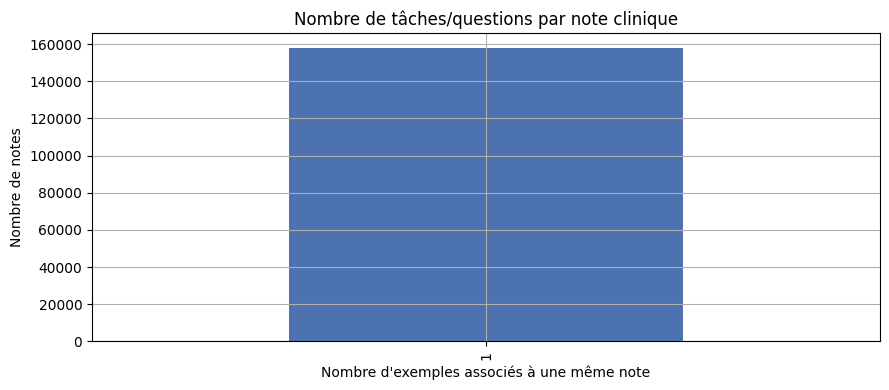

In [6]:
rows_per_note = df.groupby("note").size()
print("Nombre d'exemples par note clinique :")
print(rows_per_note.describe().round(2))

ax = rows_per_note.value_counts().sort_index().plot(kind="bar", color="#4C72B0")
ax.set_title("Nombre de tâches/questions par note clinique")
ax.set_xlabel("Nombre d'exemples associés à une même note")
ax.set_ylabel("Nombre de notes")
plt.tight_layout()
plt.show()

## 4. Distribution des types de tâches

Le dataset Asclepius couvre 8 tâches NLP cliniques. Le système MedAssist est orienté
**question-réponse** ; cette distribution montre la part de chaque tâche dans le corpus.

task
Question Answering                 20038
Abbreviation Expansion             20015
Relation Extraction                19926
Named Entity Recognition           19848
Summarization                      19756
Temporal Information Extraction    19654
Coreference Resolution             19622
Paraphrasing                       19255
Name: count, dtype: int64


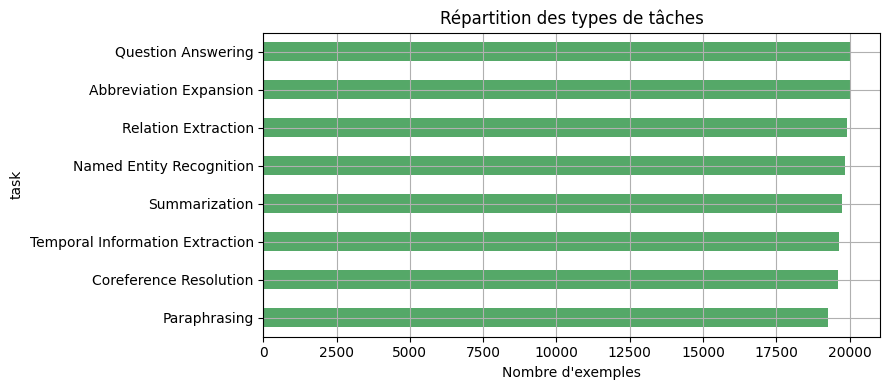

In [7]:
task_counts = df["task"].value_counts()
print(task_counts)

ax = task_counts.sort_values().plot(kind="barh", color="#55A868")
ax.set_title("Répartition des types de tâches")
ax.set_xlabel("Nombre d'exemples")
plt.tight_layout()
plt.show()

## 5. Analyse des longueurs de texte

Les longueurs des **notes** (dédoublonnées), **questions** et **réponses** déterminent
directement le paramétrage du découpage et le choix du modèle d'embedding.

In [8]:
notes = df.drop_duplicates(subset="note").copy()
notes["note_chars"] = notes["note"].str.len()
notes["note_words"] = notes["note"].str.split().str.len()
df["q_words"] = df["question"].str.split().str.len()
df["a_words"] = df["answer"].str.split().str.len()

stats = pd.DataFrame({
    "note (caractères)": notes["note_chars"].describe(),
    "note (mots)": notes["note_words"].describe(),
    "question (mots)": df["q_words"].describe(),
    "réponse (mots)": df["a_words"].describe(),
}).round(1)
stats

,note (caractères),note (mots),question (mots),réponse (mots)
count,158114.0,158114.0,158114.0,158114.0
mean,1938.1,277.4,24.3,57.7
std,566.0,82.5,6.7,29.1
min,695.0,94.0,4.0,4.0
25%,1526.0,218.0,20.0,35.0
50%,1873.0,267.0,23.0,54.0
75%,2271.0,325.0,28.0,75.0
max,5830.0,869.0,118.0,364.0


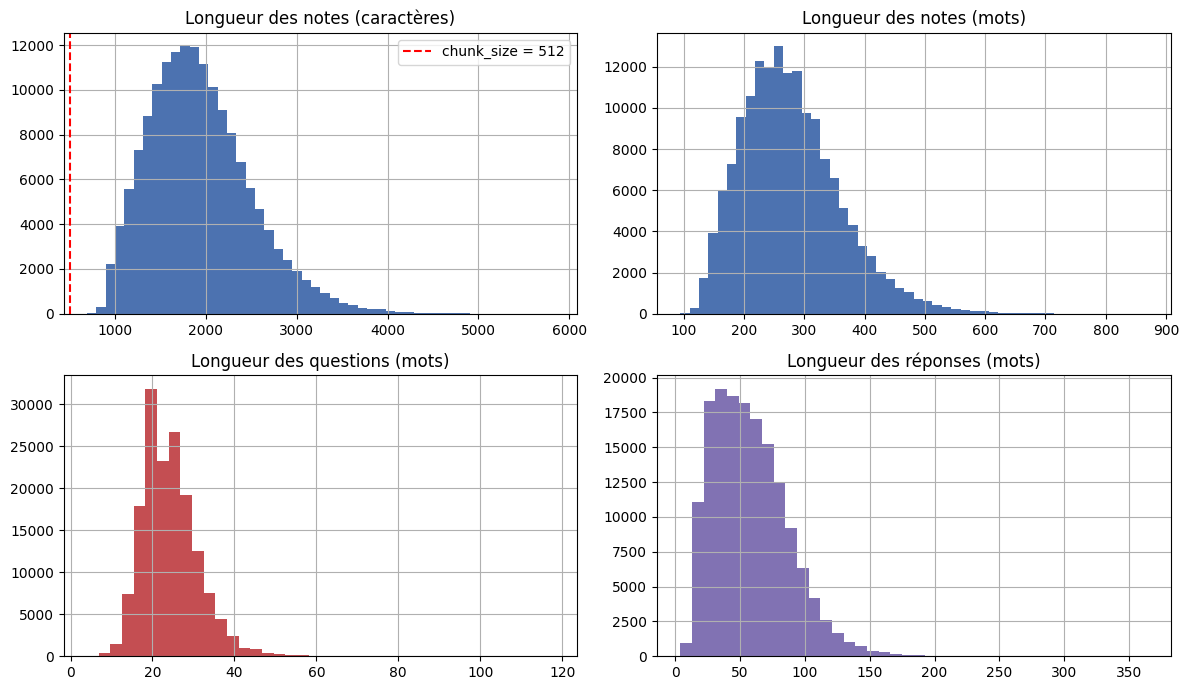

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes[0, 0].hist(notes["note_chars"], bins=50, color="#4C72B0")
axes[0, 0].axvline(512, color="red", ls="--", label="chunk_size = 512")
axes[0, 0].set_title("Longueur des notes (caractères)")
axes[0, 0].legend()
axes[0, 1].hist(notes["note_words"], bins=50, color="#4C72B0")
axes[0, 1].set_title("Longueur des notes (mots)")
axes[1, 0].hist(df["q_words"].dropna(), bins=40, color="#C44E52")
axes[1, 0].set_title("Longueur des questions (mots)")
axes[1, 1].hist(df["a_words"].dropna(), bins=40, color="#8172B3")
axes[1, 1].set_title("Longueur des réponses (mots)")
plt.tight_layout()
plt.show()

**Lecture :** la plupart des notes dépassent largement 512 caractères (ligne rouge).
Elles **doivent donc être découpées** : un seul vecteur ne représenterait pas fidèlement
une note longue, et le modèle `all-MiniLM-L6-v2` tronque au-delà de ~256 tokens.

## 6. Découpage en chunks (logique réelle du projet)

On applique **le découpage du projet** (`src.ingestion.chunker`) sur le sous-ensemble de
développement (500 notes) pour estimer le volume de l'index vectoriel.

In [10]:
from src.ingestion.chunker import chunk_documents

dev = df.head(500)
docs = [
    {"note": r["note"], "question": r["question"],
     "answer": r["answer"], "id": f"note_{i:05d}"}
    for i, (_, r) in enumerate(dev.iterrows())
]
chunks = chunk_documents(docs, chunk_size=512, chunk_overlap=50)

per_note = Counter(c.metadata["note_id"] for c in chunks)
print(f"500 documents  ->  {len(chunks):,} chunks")
print(f"Moyenne : {np.mean(list(per_note.values())):.1f} chunks / note")
print(f"Max     : {max(per_note.values())} chunks / note")

500 documents  ->  3,253 chunks
Moyenne : 6.5 chunks / note
Max     : 13 chunks / note


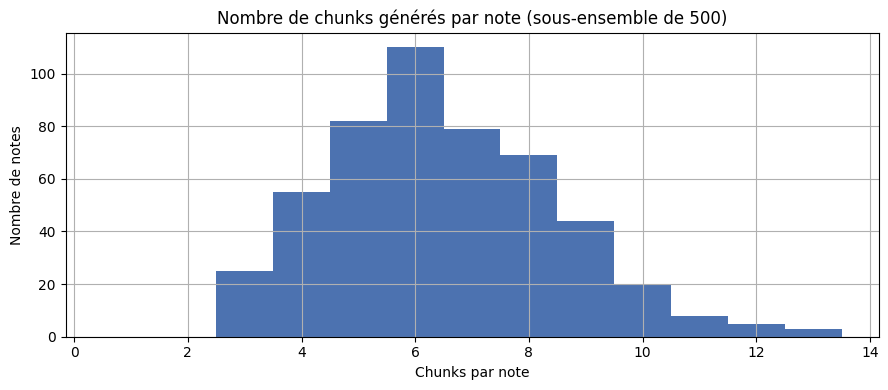

In [11]:
vals = list(per_note.values())
plt.hist(vals, bins=range(1, max(vals) + 2), color="#4C72B0", align="left")
plt.title("Nombre de chunks générés par note (sous-ensemble de 500)")
plt.xlabel("Chunks par note")
plt.ylabel("Nombre de notes")
plt.tight_layout()
plt.show()

Ces ~3 250 chunks correspondent exactement au nombre de points insérés dans Qdrant
lors de l'ingestion — l'EDA prédit donc fidèlement le dimensionnement de l'index.

## 7. Analyse en tokens vs limite du modèle d'embedding

`all-MiniLM-L6-v2` tronque les entrées au-delà de **256 tokens**. Tout chunk plus long
verrait sa fin **ignorée** lors de l'embedding. On vérifie ici avec le **vrai tokenizer**
du modèle que `chunk_size=512` caractères reste sous cette limite.

In [12]:
pip install transformers

Note: you may need to restart the kernel to use updated packages.


In [13]:
from transformers import AutoTokenizer

tokzr = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
chunk_tokens = np.array([len(tokzr.encode(c.page_content)) for c in chunks])
chunk_chars = np.array([len(c.page_content) for c in chunks])

pct_trunc = float((chunk_tokens > 256).mean() * 100)
print(f"Tokens par chunk -> moyenne {chunk_tokens.mean():.1f}, "
      f"médiane {np.median(chunk_tokens):.0f}, max {chunk_tokens.max()}")
print(f"Ratio caractères/token (moyen) : {chunk_chars.mean() / chunk_tokens.mean():.2f}")
print(f"Chunks dépassant la limite de 256 tokens : {pct_trunc:.1f}%")

Tokens par chunk -> moyenne 67.2, médiane 75, max 152
Ratio caractères/token (moyen) : 4.44
Chunks dépassant la limite de 256 tokens : 0.0%


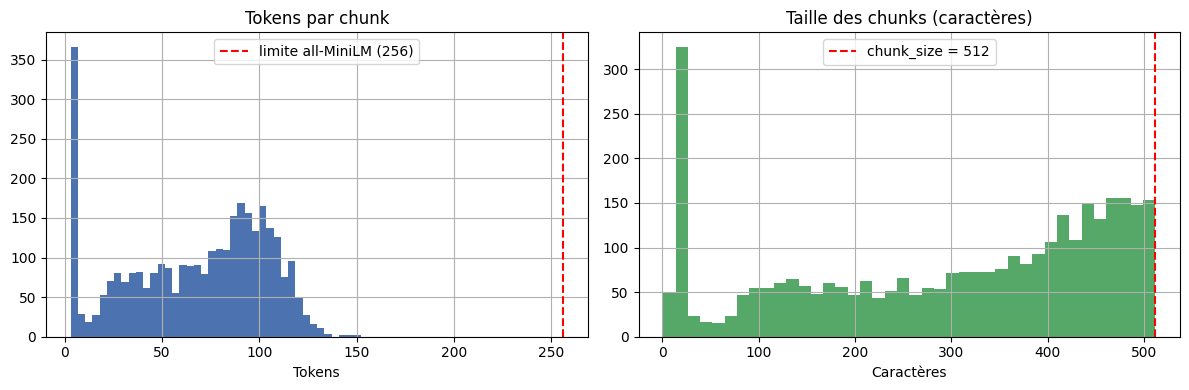

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(chunk_tokens, bins=40, color="#4C72B0")
axes[0].axvline(256, color="red", ls="--", label="limite all-MiniLM (256)")
axes[0].set_title("Tokens par chunk")
axes[0].set_xlabel("Tokens")
axes[0].legend()
axes[1].hist(chunk_chars, bins=40, color="#55A868")
axes[1].axvline(512, color="red", ls="--", label="chunk_size = 512")
axes[1].set_title("Taille des chunks (caractères)")
axes[1].set_xlabel("Caractères")
axes[1].legend()
plt.tight_layout()
plt.show()

**Conclusion clé :** avec un ratio d'environ 4 caractères/token, 512 caractères
correspondent à ~110-130 tokens — **bien en deçà de 256**. Le découpage choisi évite donc
toute troncature à l'embedding : c'est la justification quantitative de `chunk_size=512`.

## 8. Structure documentaire (sections cliniques)

Les comptes-rendus suivent une structure semi-formelle (sections séparées par des sauts de
ligne). C'est précisément ce qu'exploite le `RecursiveCharacterTextSplitter` (séparateurs
`["\n\n", "\n", ". ", " ", ""]`) pour découper sans casser le sens.

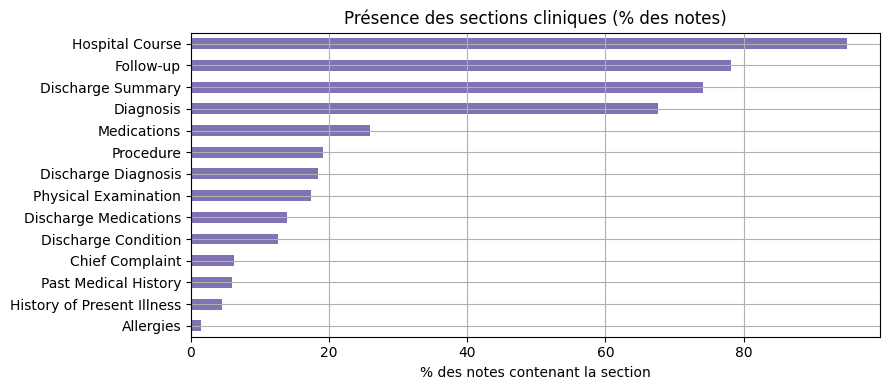

In [15]:
SECTIONS = [
    "Discharge Summary", "Hospital Course", "Chief Complaint",
    "History of Present Illness", "Past Medical History", "Physical Examination",
    "Diagnosis", "Discharge Diagnosis", "Medications", "Discharge Medications",
    "Allergies", "Procedure", "Follow-up", "Discharge Condition",
]
presence = {
    s: float(notes["note"].str.contains(s, case=False, regex=False).mean() * 100)
    for s in SECTIONS
}
presence = pd.Series(presence).sort_values()
ax = presence.plot(kind="barh", color="#8172B3")
ax.set_title("Présence des sections cliniques (% des notes)")
ax.set_xlabel("% des notes contenant la section")
plt.tight_layout()
plt.show()

## 9. Vocabulaire et termes fréquents

Aperçu du vocabulaire dominant des notes (nettoyage simple + retrait de mots-outils).
Confirme le caractère **médical/clinique** du corpus.

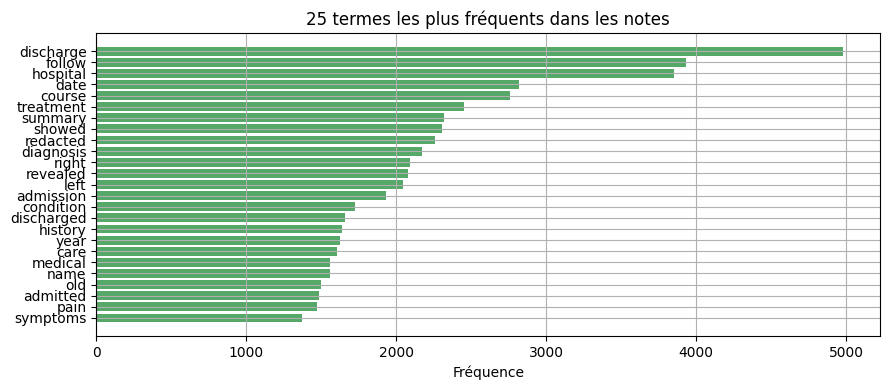

In [16]:
STOP = set(
    "the a an and or of to in for with was were is are on at by as be this that "
    "patient had has have his her their not no from after during due which been also "
    "it its she he they we were".split()
)
sample_text = " ".join(notes["note"].head(2000)).lower()
tokens = [t for t in re.findall(r"[a-z]{3,}", sample_text) if t not in STOP]
top = Counter(tokens).most_common(25)
words, freqs = zip(*top)
plt.barh(list(reversed(words)), list(reversed(freqs)), color="#55A868")
plt.title("25 termes les plus fréquents dans les notes")
plt.xlabel("Fréquence")
plt.tight_layout()
plt.show()

## 10. Exploration de l'espace d'embedding

C'est l'analyse la plus directement liée au RAG : on encode un échantillon de chunks avec
le **vrai modèle d'embedding** et on examine l'espace vectoriel sur lequel repose le
retrieval (séparabilité, regroupement par note).

In [17]:
from sentence_transformers import SentenceTransformer

emb_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(chunks), size=min(1000, len(chunks)), replace=False)
sample = [chunks[i] for i in sample_idx]
texts = [c.page_content for c in sample]
emb = emb_model.encode(texts, normalize_embeddings=True, show_progress_bar=False)
print("Matrice d'embeddings :", emb.shape)

Matrice d'embeddings : (1000, 384)


### 10.1 Distribution des similarités cosinus entre chunks

Si la plupart des paires ont une similarité **basse**, l'espace est bien étalé : le
retrieval pourra distinguer les passages pertinents. Une queue à droite révèle des
quasi-doublons (souvent des chunks d'une même note).

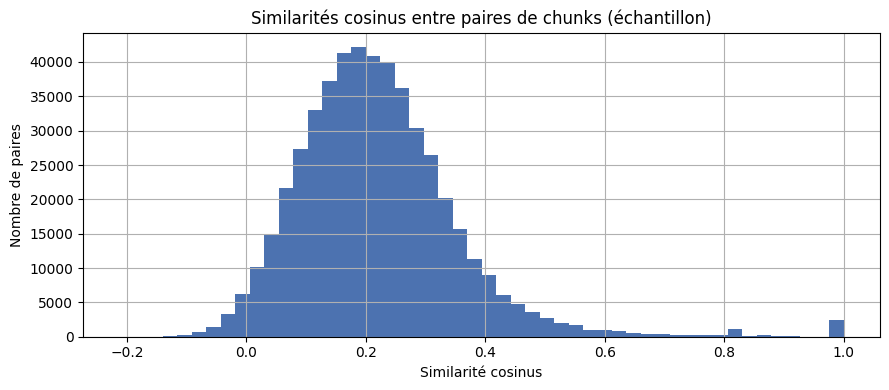

Similarité moyenne 0.219 | médiane 0.206


In [18]:
sim = emb @ emb.T
iu = np.triu_indices(len(emb), k=1)
pair = sim[iu]
plt.hist(pair, bins=50, color="#4C72B0")
plt.title("Similarités cosinus entre paires de chunks (échantillon)")
plt.xlabel("Similarité cosinus")
plt.ylabel("Nombre de paires")
plt.tight_layout()
plt.show()
print(f"Similarité moyenne {pair.mean():.3f} | médiane {np.median(pair):.3f}")

### 10.2 Projection PCA colorée par note source

On projette les embeddings en 2D. Les chunks issus d'une **même note** devraient se
regrouper : c'est ce qui rend le filtrage par `note_id` et la citation des sources
pertinents.

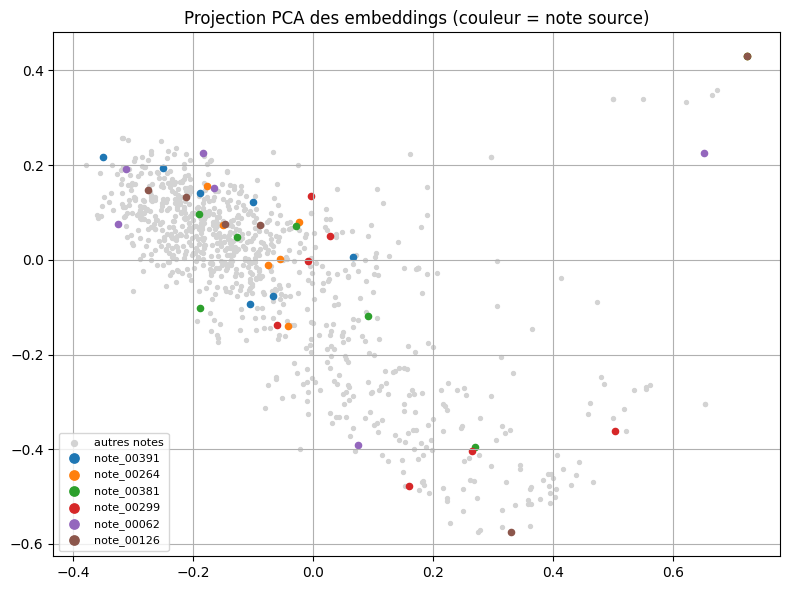

In [19]:
from sklearn.decomposition import PCA

nids = np.array([c.metadata["note_id"] for c in sample])
top_notes = [n for n, _ in Counter(nids).most_common(6)]
proj = PCA(n_components=2).fit_transform(emb)

plt.figure(figsize=(8, 6))
other = ~np.isin(nids, top_notes)
plt.scatter(proj[other, 0], proj[other, 1], s=8, c="lightgrey", label="autres notes")
for n in top_notes:
    m = nids == n
    plt.scatter(proj[m, 0], proj[m, 1], s=20, label=n)
plt.title("Projection PCA des embeddings (couleur = note source)")
plt.legend(fontsize=8, markerscale=1.5)
plt.tight_layout()
plt.show()

## 11. Démonstration concrète de récupération (retrieval)

On simule le cœur du RAG : une requête est encodée, puis comparée par similarité cosinus
à l'échantillon de chunks. Voici les **5 passages les plus proches** — exactement ce que
le système enverrait à Claude comme contexte.

In [20]:
query = "What medications were prescribed to the patient?"
qv = emb_model.encode(query, normalize_embeddings=True)
scores = emb @ qv
order = np.argsort(-scores)[:5]

print("Requête :", query, "\n")
for rank, i in enumerate(order, 1):
    print(f"#{rank}  {sample[i].metadata['note_id']}  score={float(scores[i]):.3f}")
    print("    " + texts[i][:180].replace("\n", " ") + " ...\n")

Requête : What medications were prescribed to the patient? 

#1  note_00046  score=0.605
    Upon admission, the patient was started on IV fluid therapy with normal saline solution due to dehydration, bradycardia, and hypotension. Norepinephrine was also administered. The  ...

#2  note_00071  score=0.577
    . Despite multiple medication trials, including escitalopram, benztropine, clonazepam, clonidine, sertraline, haloperidol, risperidone, guanfacine, and aripiprazole, all at maximum ...

#3  note_00055  score=0.575
    Medications:  Information not disclosed.  Follow-up:  The patient is scheduled for a follow-up appointment. ...

#4  note_00288  score=0.570
    . The patient was given several treatment options, including CHOP chemotherapy, oral thalidomide, and steroid therapy, but he refused and chose to manage his symptoms with oral diu ...

#5  note_00342  score=0.553
    A 71-year-old male was admitted to the hospital due to productive cough, low grade fever, chest pain and sho

## 12. Implications pour la conception du RAG (synthèse)

| Observation (EDA) | Décision de conception |
|---|---|
| Notes longues (souvent > 1 000 caractères) ; modèle limité à 256 tokens | **Découpage** en chunks de `512` caractères, `overlap=50` |
| 512 caractères ≈ 110-130 tokens (< 256) → 0 % de troncature | `chunk_size=512` validé quantitativement |
| ~3 250 chunks pour 500 notes | Index Qdrant dimensionné ; insertion par batches de 100 |
| Documents semi-structurés (sections cliniques) | Splitter récursif par paragraphes (`\n\n`) |
| Espace d'embedding bien étalé, chunks regroupés par note | `top_k=5` suffisant ; `note_id` conservé pour citer/filtrer/dédoublonner |
| Une note → plusieurs tâches/questions | On indexe le **texte des notes**, pas les paires Q/R |
| Présence d'un `patient_id` | Métadonnée conservable pour cibler une requête sur un patient |
| Corpus anglais, vocabulaire clinique | Embeddings `all-MiniLM-L6-v2` (384 dim) + prompt anti-hallucination |

## 13. Conclusion

Le corpus Asclepius est **propre**, **volumineux** et **redondant par construction** (une
note réutilisée pour 8 types de tâches). Les notes sont assez longues pour **exiger un
découpage**, et l'analyse en tokens confirme que `chunk_size=512` reste sous la limite du
modèle. L'exploration de l'espace d'embedding montre un espace **séparable** où les chunks
d'une même note se regroupent — condition favorable à un retrieval fiable.

Cette EDA constitue la **justification quantitative, en amont**, des choix d'implémentation
du système MedAssist (`chunk_size=512`, `overlap=50`, `top_k=5`, `all-MiniLM-L6-v2`,
métadonnées `note_id`/`patient_id`).